In [1]:
import cv2
import os
import numpy as np
import mediapipe as mp
import pandas as pd
import random

In [9]:
BASE_DATASET = r'F:\Dataset Ta\DATASET\DAISEE\DataSet'
LABEL_DIR = r'F:\Dataset Ta\DATASET\DAISEE\Labels'
OUTPUT_DIR = r'F:\Dataset Ta\DATASET\Output_Faces_V1.1'

In [4]:
import urllib.request
import os

# Unduh arsitektur dan bobot model DNN SSD ResNet-10 jika belum ada
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
caffemodel_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists("deploy.prototxt"):
    urllib.request.urlretrieve(prototxt_url, "deploy.prototxt")
if not os.path.exists("res10_300x300_ssd_iter_140000.caffemodel"):
    urllib.request.urlretrieve(caffemodel_url, "res10_300x300_ssd_iter_140000.caffemodel")

# Inisialisasi model pendeteksi wajah OpenCV DNN
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

In [5]:
# === Fungsi ekstraksi wajah dari video ===
def extract_faces_from_video(video_path, save_dir, clip_id):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = int(fps)  # 1 frame per detik
    target_frame = 0
    frame_num = 0
    saved = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_num == target_frame:
            h, w = frame.shape[:2]
            
            # Pre-processing frame untuk model DNN
            blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
            net.setInput(blob)
            detections = net.forward()

            if detections.shape[2] > 0:
                for i in range(detections.shape[2]):
                    confidence = detections[0, 0, i, 2]

                    # Gunakan threshold confidence 0.5 (50%) untuk memfilter deteksi yang lemah
                    if confidence > 0.5:
                        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                        (startX, startY, endX, endY) = box.astype("int")

                        # Pastikan koordinat bounding box tidak melewati batas dimensi frame asli
                        startX = max(0, startX)
                        startY = max(0, startY)
                        endX = min(w, endX)
                        endY = min(h, endY)

                        face = frame[startY:endY, startX:endX]

                        if face.size > 0:
                            os.makedirs(save_dir, exist_ok=True)
                            filename = os.path.join(save_dir, f"{clip_id}_sec{frame_num//int(fps)}.jpg")
                            cv2.imwrite(filename, face)
                            saved += 1

            target_frame += frame_interval  # Update target frame

        frame_num += 1

    cap.release()
    return saved

In [6]:
def get_balanced_clip_ids(label_file):
    print(f"\nMembaca label dari: {label_file}")
    label_df = pd.read_csv(os.path.join(LABEL_DIR, label_file))

    # Relabeling berdasarkan aturan paper
    def relabel(row):
        e, c = row['Engagement'], row['Confusion']
        if e == 0:
            return 0  # Disengaged
        elif e == 3:
            return 1  # Engaged
        elif (c == 0 or c == 3) and e == 1:
            return 0  # Disengaged
        else:
            return 1  # Engaged

    label_df['NewLabel'] = label_df.apply(relabel, axis=1)

    # Kelompokkan clip_id per kelas
    label_groups = {
        0: label_df[label_df['NewLabel'] == 0]['ClipID'].tolist(),
        1: label_df[label_df['NewLabel'] == 1]['ClipID'].tolist()
    }

    min_count = min(len(label_groups[0]), len(label_groups[1]))
    print(f"Disengaged Video: {len(label_groups[0])}, Engaged Video: {len(label_groups[1])}")
    print(f"Balancing ke {min_count} video per kelas")

    balanced_clips = {
        0: set(random.sample(label_groups[0], min_count)),
        1: set(random.sample(label_groups[1], min_count))
    }

    return balanced_clips

In [7]:
def process_split_balanced(split_name, label_file, balanced_clips):
    print(f"\nEkstraksi balanced video dari split: {split_name}")
    label_df = pd.read_csv(os.path.join(LABEL_DIR, label_file))

    # Relabel ulang
    def relabel(row):
        e, c = row['Engagement'], row['Confusion']
        if e == 0:
            return 0
        elif e == 3:
            return 1
        elif (c == 0 or c == 3) and e == 1:
            return 0
        else:
            return 1

    label_df['NewLabel'] = label_df.apply(relabel, axis=1)
    label_map = dict(zip(label_df['ClipID'], label_df['NewLabel']))

    split_path = os.path.join(BASE_DATASET, split_name)
    for subject in os.listdir(split_path):
        subject_path = os.path.join(split_path, subject)
        for video_id in os.listdir(subject_path):
            video_folder = os.path.join(subject_path, video_id)
            for file in os.listdir(video_folder):
                if file.endswith('.avi'):
                    clip_id = file
                    label = label_map.get(clip_id)
                    if label is None:
                        continue

                    # Hanya proses clip_id yang termasuk dalam balancing
                    if clip_id not in balanced_clips[label]:
                        continue

                    video_path = os.path.join(video_folder, file)
                    save_path = os.path.join(OUTPUT_DIR, split_name.lower(), str(label))
                    count = extract_faces_from_video(video_path, save_path, clip_id)
                    print(f"Done {clip_id} → {count} wajah → label {label}")

In [10]:
train_balanced = get_balanced_clip_ids("TrainLabels.csv")
process_split_balanced("Train", "TrainLabels.csv", train_balanced)


Membaca label dari: TrainLabels.csv
Disengaged Video: 148, Engaged Video: 5210
Balancing ke 148 video per kelas

Ekstraksi balanced video dari split: Train
Done 1100011029.avi → 10 wajah → label 1
Done 1100011054.avi → 10 wajah → label 1
Done 1100011055.avi → 10 wajah → label 1
Done 1100012001.avi → 15 wajah → label 1
Done 1100012023.avi → 10 wajah → label 1
Done 1100021003.avi → 10 wajah → label 0
Done 1100021045.avi → 10 wajah → label 1
Done 1100021055.avi → 10 wajah → label 0
Done 1100022005.avi → 10 wajah → label 0
Done 1100022029.avi → 10 wajah → label 1
Done 1100022054.avi → 10 wajah → label 1
Done 1100042059.avi → 10 wajah → label 1
Done 1100051020.avi → 10 wajah → label 1
Done 1100051030.avi → 10 wajah → label 0
Done 1100051031.avi → 10 wajah → label 0
Done 1100051049.avi → 10 wajah → label 1
Done 1100051052.avi → 10 wajah → label 1
Done 1100051053.avi → 10 wajah → label 0
Done 1100052014.avi → 10 wajah → label 0
Done 1100071063.avi → 10 wajah → label 1
Done 1100071067.avi → 1

In [11]:
val_balanced = get_balanced_clip_ids("ValidationLabels.csv")
process_split_balanced("Validation", "ValidationLabels.csv", val_balanced)


Membaca label dari: ValidationLabels.csv
Disengaged Video: 104, Engaged Video: 1325
Balancing ke 104 video per kelas

Ekstraksi balanced video dari split: Validation
Done 4000221042.avi → 10 wajah → label 1
Done 4000222031.avi → 10 wajah → label 0
Done 4000222032.avi → 10 wajah → label 0
Done 4000222036.avi → 10 wajah → label 0
Done 4000222039.avi → 10 wajah → label 1
Done 4000222041.avi → 10 wajah → label 0
Done 4000222054.avi → 10 wajah → label 1
Done 4000231047.avi → 10 wajah → label 1
Done 4000232006.avi → 10 wajah → label 1
Done 4000232071.avi → 10 wajah → label 0
Done 4000301005.avi → 10 wajah → label 0
Done 4000301010.avi → 10 wajah → label 0
Done 4000301011.avi → 10 wajah → label 0
Done 4000301021.avi → 10 wajah → label 0
Done 4000301028.avi → 10 wajah → label 0
Done 4000301030.avi → 10 wajah → label 0
Done 4000301038.avi → 10 wajah → label 1
Done 4000301042.avi → 10 wajah → label 0
Done 4000301049.avi → 10 wajah → label 0
Done 4000301054.avi → 10 wajah → label 1
Done 40003010

In [12]:
test_balanced = get_balanced_clip_ids("TestLabels.csv")
process_split_balanced("Test", "TestLabels.csv", test_balanced)


Membaca label dari: TestLabels.csv
Disengaged Video: 52, Engaged Video: 1732
Balancing ke 52 video per kelas

Ekstraksi balanced video dari split: Test
Done 5000441007.avi → 10 wajah → label 1
Done 5000441024.avi → 10 wajah → label 1
Done 5000441031.avi → 10 wajah → label 1
Done 5000441052.avi → 10 wajah → label 1
Done 5000441058.avi → 10 wajah → label 0
Done 5000441067.avi → 10 wajah → label 0
Done 5000442059.avi → 10 wajah → label 1
Done 5000671041.avi → 10 wajah → label 0
Done 5000671048.avi → 10 wajah → label 0
Done 5000671049.avi → 10 wajah → label 0
Done 5000671058.avi → 10 wajah → label 0
Done 5000671069.avi → 10 wajah → label 0
Done 5000672057.avi → 10 wajah → label 1
Done 5000951023.avi → 10 wajah → label 0
Done 5000951049.avi → 10 wajah → label 1
Done 5000952040.avi → 10 wajah → label 1
Done 5000952062.avi → 10 wajah → label 0
Done 5000952083.avi → 10 wajah → label 0
Done 5100091008.avi → 10 wajah → label 1
Done 5100091049.avi → 10 wajah → label 0
Done 5100091059.avi → 10 wa

In [14]:
import os, shutil
from sklearn.model_selection import train_test_split
from collections import defaultdict

In [15]:
base_path = r'F:\Dataset Ta\DATASET\Output_Faces_V1.1'
merged_list = []
labels = []

In [16]:
for split in ["train", "validation", "test"]:
    for label in ['0', '1']:
        folder = os.path.join(base_path, split, label)
        for fname in os.listdir(folder):
            if fname.endswith('.jpg'):
                merged_list.append(os.path.join(folder, fname))
                labels.append(int(label))

print(f"Total data gabungan: {len(merged_list)}")

Total data gabungan: 5811


In [17]:
# split: 70% train, 15% val, 15% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    merged_list, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

In [18]:
def copy_files(file_list, label_list, split_name):
    for path, label in zip(file_list, label_list):
        dst_dir = os.path.join(base_path + "_resplit", split_name, str(label))
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(path, os.path.join(dst_dir, os.path.basename(path)))

In [19]:
# copy files ke folder baru
copy_files(train_paths, train_labels, "train")
copy_files(val_paths, val_labels, "val")
copy_files(test_paths, test_labels, "test")

In [20]:
DATA_DIR = r'F:\Dataset Ta\DATASET\Output_Faces_V1.1_resplit'
for split in ['train', 'val', 'test']:
    total = 0
    print(f"\n[📁 Split: {split}]")
    for label in ['0', '1']:
        count = len(os.listdir(os.path.join(DATA_DIR, split, label)))
        print(f"  Label {label}: {count} gambar")
        total += count
    print(f"  Total: {total} gambar")


[📁 Split: train]
  Label 0: 2093 gambar
  Label 1: 1974 gambar
  Total: 4067 gambar

[📁 Split: val]
  Label 0: 448 gambar
  Label 1: 424 gambar
  Total: 872 gambar

[📁 Split: test]
  Label 0: 449 gambar
  Label 1: 423 gambar
  Total: 872 gambar


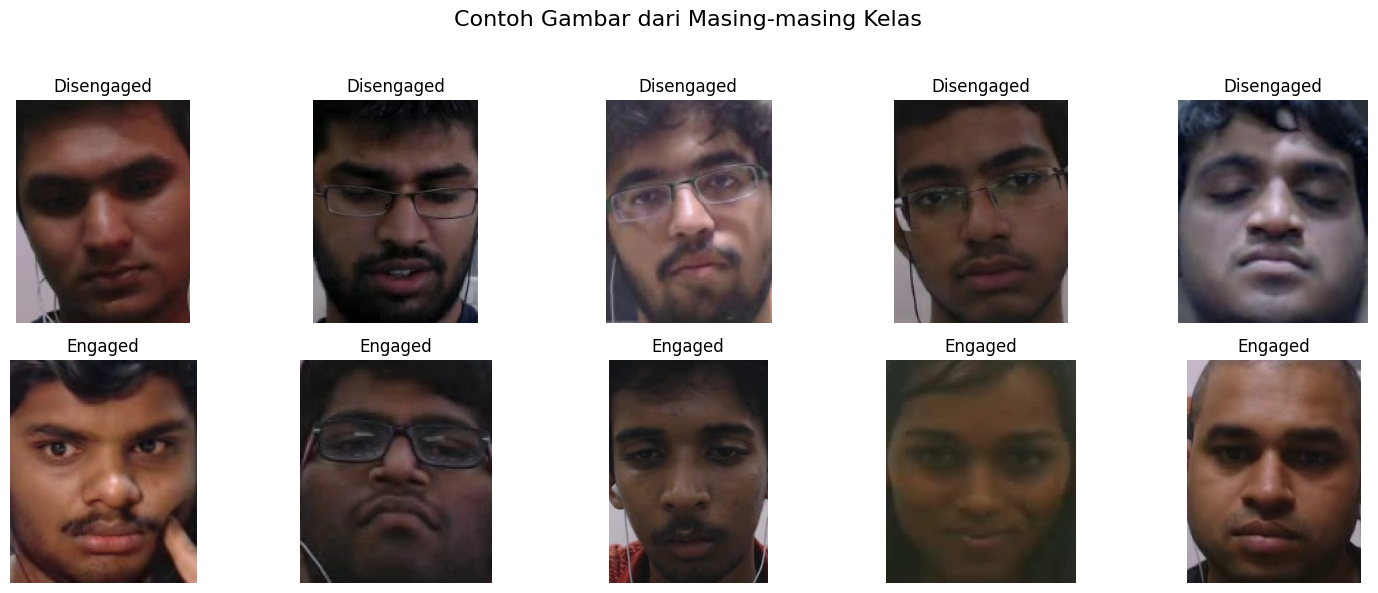

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = DATA_DIR + '/train'

labels = {'0': 'Disengaged', '1': 'Engaged'}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Contoh Gambar dari Masing-masing Kelas", fontsize=16)

for i, label in enumerate(['0', '1']):
    class_dir = os.path.join(dataset_path, label)
    sample_images = random.sample(os.listdir(class_dir), 5)
    
    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path)
        
        ax = axes[i][j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{labels[label]}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# resize

In [22]:
import os
import cv2
import shutil

In [23]:
INPUT_DIR = r'F:\Dataset Ta\DATASET\Output_Faces_V1.1_resplit'
OUTPUT_DIR = r"F:\Dataset Ta\DATASET\Output_Faces_V1.1_resplit_224"
TARGET_SIZE = (224, 224)

In [ ]:


# =========================================================
# HAPUS OUTPUT LAMA
# =========================================================

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Mulai proses resize...\n")

total_images = 0

# =========================================================
# RESIZE
# =========================================================

for root, dirs, files in os.walk(INPUT_DIR):

    relative = os.path.relpath(root, INPUT_DIR)

    save_dir = os.path.join(
        OUTPUT_DIR,
        relative
    )

    os.makedirs(save_dir, exist_ok=True)

    for file in files:

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        resized = cv2.resize(
            img,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

        cv2.imwrite(
            os.path.join(save_dir, file),
            resized
        )

        total_images += 1

        if total_images % 1000 == 0:
            print(f"{total_images} gambar selesai...")

print("\n===================================")
print("Resize selesai")
print(f"Total gambar : {total_images}")
print("Ukuran akhir : 224 x 224")
print("Folder output:")
print(OUTPUT_DIR)
print("===================================")

Mulai proses resize...

1000 gambar selesai...
2000 gambar selesai...
3000 gambar selesai...
4000 gambar selesai...
5000 gambar selesai...

Resize selesai
Total gambar : 5811
Ukuran akhir : 224 x 224
Folder output:
F:\Dataset Ta\DATASET\Output_Faces_V1.1_resplit_224


In [26]:
import os

OUTPUT_DIR = r"F:\Dataset Ta\DATASET\Output_Faces_V1.1_resplit_224"

def cek_video(nama_folder):
    kumpulan_id = set()
    jalur_folder = os.path.join(OUTPUT_DIR, nama_folder)
    if not os.path.exists(jalur_folder):
        return kumpulan_id
    for label in ["0", "1"]:
        jalur_label = os.path.join(jalur_folder, label)
        if not os.path.exists(jalur_label):
            continue
        for file in os.listdir(jalur_label):
            if file.endswith(".jpg"):
                id_video = file.split("_")[0]
                kumpulan_id.add(id_video)
    return kumpulan_id

video_train = cek_video("Train")
video_val = cek_video("Validation")
video_test = cek_video("Test")

bocor_train_val = video_train.intersection(video_val)
bocor_train_test = video_train.intersection(video_test)
bocor_val_test = video_val.intersection(video_test)

print("Jumlah bocor Train dan Validation:", len(bocor_train_val))
print("Jumlah bocor Train dan Test:", len(bocor_train_test))
print("Jumlah bocor Validation dan Test:", len(bocor_val_test))

Jumlah bocor Train dan Validation: 0
Jumlah bocor Train dan Test: 0
Jumlah bocor Validation dan Test: 0
